In [1]:
#============================================================
# Celda 1 — Setup y carga
#============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from linearmodels.panel import PanelOLS, PooledOLS

# Funciona en local (Codespaces/Jupyter), CI (papermill) y cualquier entorno
ROOT = Path.cwd()
while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "requirements.txt").exists():
    raise FileNotFoundError(
        f"No se encontró requirements.txt subiendo desde {Path.cwd()}\n"
        "Asegúrate de ejecutar desde dentro del repo."
    )
os.chdir(ROOT)
print(f"✅ ROOT: {ROOT}")

OUTPUT = Path("output")
FIGS   = OUTPUT / "07_regresion" / "figs"
TABLES = OUTPUT / "07_regresion" / "tables"
FIGS.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

master = pd.read_parquet(OUTPUT / "merged/master_provincia_anio.parquet")

VARS_MODEL = ["saldo_neto", "compraventas_vivienda", "cob_100mbps_pct",
              "poblacion_provincia", "compraventas_per_capita", "tasa_atraccion"]

sub = master[["anyo", "provincia"] + VARS_MODEL].dropna().copy()

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

print(f"✅ Subconjunto: {sub.shape} | años: 2013–2021 | provincias: {sub['provincia'].nunique()}")

✅ ROOT: /workspaces/TFG_Spain-s_Migratory_Flow
✅ Subconjunto: (1377, 8) | años: 2013–2021 | provincias: 51


In [2]:
#============================================================
# Celda 2 — VIF: detección de multicolinealidad
#============================================================
X_vars = ["compraventas_vivienda", "cob_100mbps_pct",
          "poblacion_provincia", "compraventas_per_capita"]

X_vif = sub[X_vars].copy()
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    "Variable": X_vars,
    "VIF": [variance_inflation_factor(X_vif_const.values, i+1)
            for i in range(len(X_vars))]
}).sort_values("VIF", ascending=False).round(2)

print("📊 Factor de Inflación de Varianza (VIF)\n")
print(vif_data.to_string(index=False))
print("\n  VIF > 10 → multicolinealidad severa (eliminar variable)")
print("  VIF 5–10 → multicolinealidad moderada (revisar)")
print("  VIF < 5  → aceptable ✅")

vif_data.to_csv(TABLES / "vif_multicolinealidad.csv", index=False)

📊 Factor de Inflación de Varianza (VIF)

               Variable  VIF
  compraventas_vivienda 7.05
    poblacion_provincia 6.30
compraventas_per_capita 1.98
        cob_100mbps_pct 1.20

  VIF > 10 → multicolinealidad severa (eliminar variable)
  VIF 5–10 → multicolinealidad moderada (revisar)
  VIF < 5  → aceptable ✅


In [3]:
#============================================================
# Celda 3 — OLS múltiple (modelo base)
#============================================================
formula_base = ("saldo_neto ~ compraventas_vivienda + cob_100mbps_pct "
                "+ poblacion_provincia")

modelo_base = smf.ols(formula_base, data=sub).fit()
print(modelo_base.summary())

# Exportar summary
with open(TABLES / "ols_base_summary.txt", "w") as f:
    f.write(str(modelo_base.summary()))

print(f"\n  R²        = {modelo_base.rsquared:.4f}")
print(f"  R² adj    = {modelo_base.rsquared_adj:.4f}")
print(f"  F-stat    = {modelo_base.fvalue:.2f}  (p={modelo_base.f_pvalue:.4f})")
print(f"  N obs     = {int(modelo_base.nobs)}")

                            OLS Regression Results                            
Dep. Variable:             saldo_neto   R-squared:                       0.410
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     318.5
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          6.14e-157
Time:                        08:32:06   Log-Likelihood:                -14787.
No. Observations:                1377   AIC:                         2.958e+04
Df Residuals:                    1373   BIC:                         2.960e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              1970.12

In [4]:
#============================================================
# Celda 4 — OLS extendido
#============================================================
formula_ext = ("saldo_neto ~ compraventas_vivienda + cob_100mbps_pct "
               "+ poblacion_provincia + compraventas_per_capita")

modelo_ext = smf.ols(formula_ext, data=sub).fit()
print(modelo_ext.summary())

with open(TABLES / "ols_extendido_summary.txt", "w") as f:
    f.write(str(modelo_ext.summary()))

# Comparativa de modelos
comp = pd.DataFrame({
    "Modelo":    ["OLS Base", "OLS Extendido"],
    "Variables": [3, 4],
    "R²":        [round(modelo_base.rsquared, 4),     round(modelo_ext.rsquared, 4)],
    "R² adj":    [round(modelo_base.rsquared_adj, 4), round(modelo_ext.rsquared_adj, 4)],
    "AIC":       [round(modelo_base.aic, 1),          round(modelo_ext.aic, 1)],
    "BIC":       [round(modelo_base.bic, 1),          round(modelo_ext.bic, 1)],
    "F p-value": [round(modelo_base.f_pvalue, 5),     round(modelo_ext.f_pvalue, 5)],
})
print("\n📊 Comparativa de modelos OLS:")
print(comp.to_string(index=False))
comp.to_csv(TABLES / "comparativa_modelos.csv", index=False)

                            OLS Regression Results                            
Dep. Variable:             saldo_neto   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                     239.8
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          3.21e-156
Time:                        08:32:06   Log-Likelihood:                -14786.
No. Observations:                1377   AIC:                         2.958e+04
Df Residuals:                    1372   BIC:                         2.961e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [5]:
#============================================================
# Celda 5 — Panel Data: Fixed Effects (within estimator)
#============================================================
# Preparar índice panel: (provincia, anyo)
panel = sub.copy()
panel = panel.set_index(["provincia", "anyo"])

# Variables
dep   = panel["saldo_neto"]
exog  = sm.add_constant(panel[["compraventas_vivienda",
                                "cob_100mbps_pct",
                                "compraventas_per_capita"]])

# Fixed Effects (absorbe heterogeneidad no observable por provincia)
fe_model = PanelOLS(dep, exog, entity_effects=True, time_effects=False)
fe_result = fe_model.fit(cov_type="clustered", cluster_entity=True)

print(fe_result.summary)

with open(TABLES / "panel_fe_summary.txt", "w") as f:
    f.write(str(fe_result.summary))

print(f"\n  R² within  = {fe_result.rsquared_within:.4f}")
print(f"  R² between = {fe_result.rsquared_between:.4f}")
print(f"  R² overall = {fe_result.rsquared_overall:.4f}")
print(f"  N obs      = {fe_result.nobs}")

                          PanelOLS Estimation Summary                           
Dep. Variable:             saldo_neto   R-squared:                        0.0023
Estimator:                   PanelOLS   R-squared (Between):              0.0960
No. Observations:                1377   R-squared (Within):               0.0023
Date:                Wed, Apr 15 2026   R-squared (Overall):              0.0505
Time:                        08:32:06   Log-likelihood                -1.465e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.0129
Entities:                          51   P-value                           0.3861
Avg Obs:                       27.000   Distribution:                  F(3,1323)
Min Obs:                       27.000                                           
Max Obs:                       27.000   F-statistic (robust):             0.6636
                            

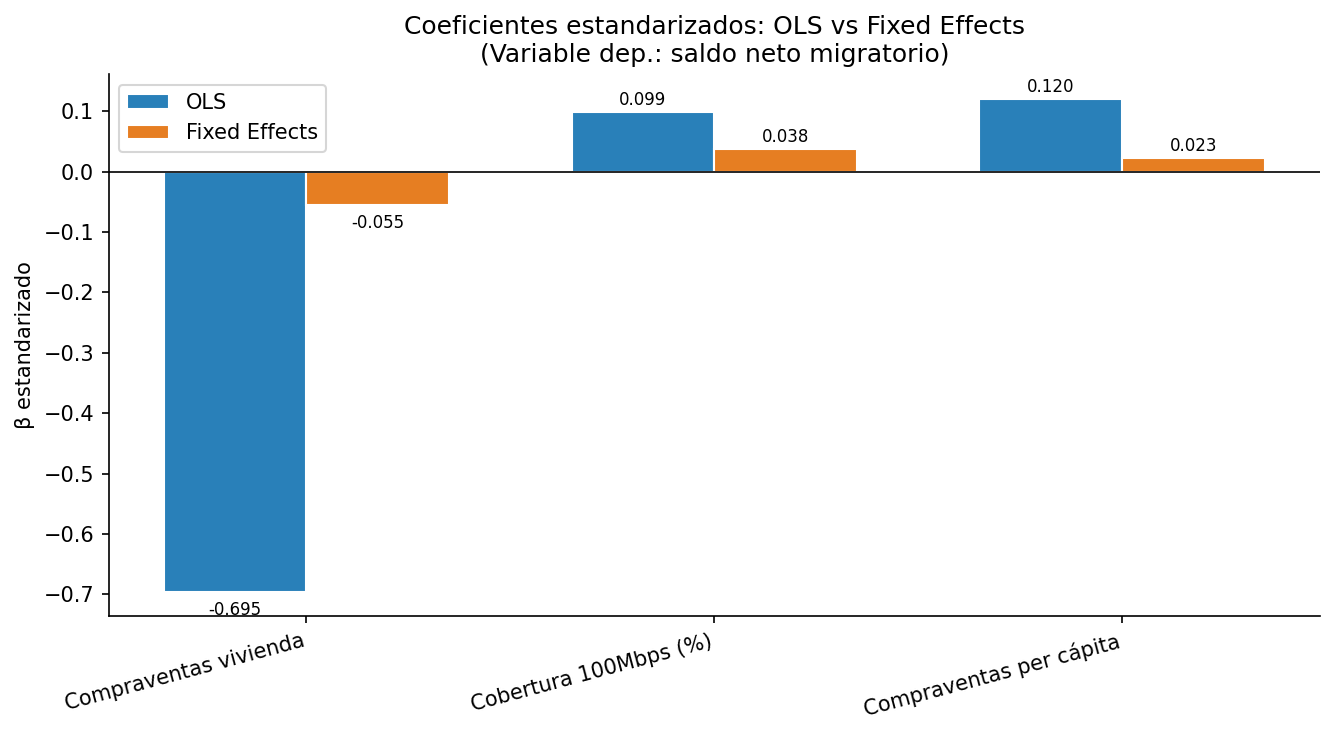

✅ Guardado: 01_coeficientes_ols_vs_fe.png


In [6]:
#============================================================
# Celda 6 — Comparativa coeficientes OLS vs Fixed Effects
#============================================================
vars_plot = ["compraventas_vivienda", "cob_100mbps_pct", "compraventas_per_capita"]

LABELS = {
    "compraventas_vivienda":  "Compraventas vivienda",
    "cob_100mbps_pct":        "Cobertura 100Mbps (%)",
    "compraventas_per_capita":"Compraventas per cápita",
}

# Estandarizar para comparar coeficientes
scaler = StandardScaler()
sub_std = sub.copy()
sub_std[vars_plot + ["saldo_neto"]] = scaler.fit_transform(
    sub[vars_plot + ["saldo_neto"]]
)

ols_std  = smf.ols(
    "saldo_neto ~ compraventas_vivienda + cob_100mbps_pct + compraventas_per_capita",
    data=sub_std
).fit()

panel_std = sub_std.set_index(["provincia", "anyo"])
fe_std = PanelOLS(
    panel_std["saldo_neto"],
    sm.add_constant(panel_std[vars_plot]),
    entity_effects=True
).fit(cov_type="clustered", cluster_entity=True)

# Construir dataframe comparativo
coef_df = pd.DataFrame({
    "Variable": [LABELS[v] for v in vars_plot],
    "OLS (β std)": [ols_std.params[v] for v in vars_plot],
    "FE  (β std)": [fe_std.params[v] for v in vars_plot],
})

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(vars_plot))
w = 0.35

bars1 = ax.bar(x - w/2, coef_df["OLS (β std)"], width=w,
               label="OLS", color="#2980b9", edgecolor="white")
bars2 = ax.bar(x + w/2, coef_df["FE  (β std)"], width=w,
               label="Fixed Effects", color="#e67e22", edgecolor="white")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(coef_df["Variable"], rotation=15, ha="right")
ax.set_title("Coeficientes estandarizados: OLS vs Fixed Effects\n(Variable dep.: saldo neto migratorio)")
ax.set_ylabel("β estandarizado")
ax.legend()

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            h + (0.005 if h >= 0 else -0.015),
            f"{h:.3f}", ha="center", va="bottom" if h >= 0 else "top", fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / "01_coeficientes_ols_vs_fe.png")
plt.show()
coef_df.to_csv(TABLES / "coeficientes_comparativa.csv", index=False)
print("✅ Guardado: 01_coeficientes_ols_vs_fe.png")

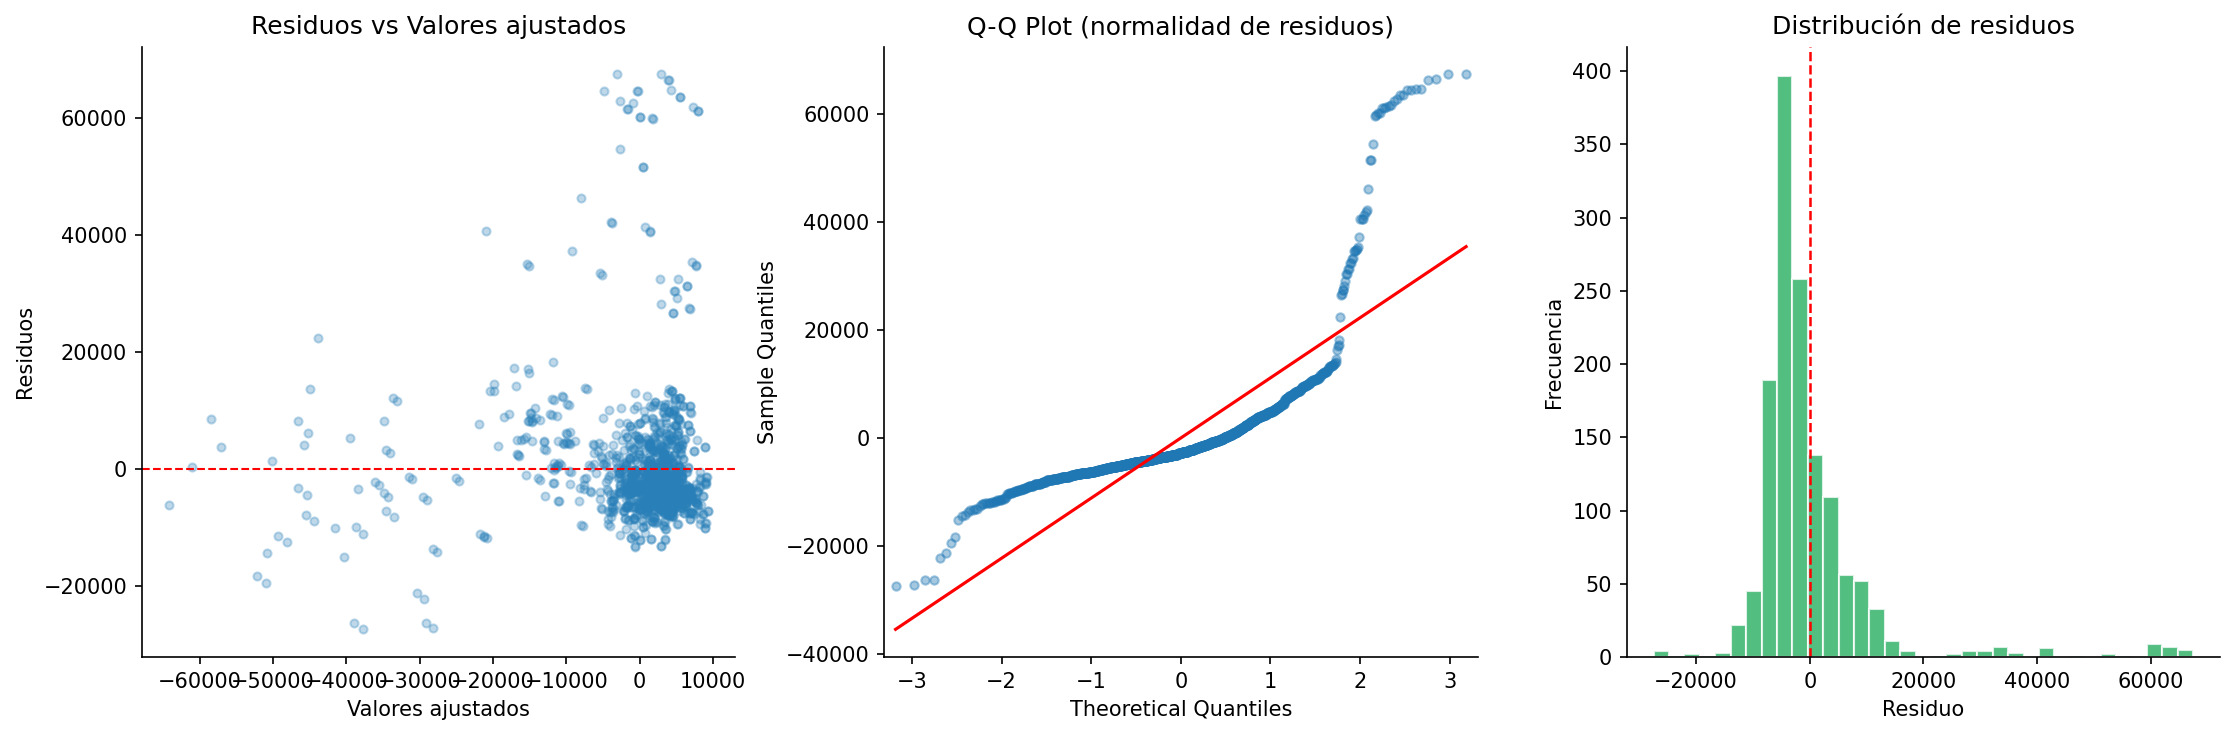

✅ Guardado: 02_diagnostico_residuos.png


In [7]:
#============================================================
# Celda 7 — Diagnóstico de residuos
#============================================================
residuos   = modelo_ext.resid
fitted     = modelo_ext.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Residuos vs Fitted
axes[0].scatter(fitted, residuos, alpha=0.3, s=15, color="#2980b9")
axes[0].axhline(0, color="red", linewidth=1, linestyle="--")
axes[0].set_title("Residuos vs Valores ajustados")
axes[0].set_xlabel("Valores ajustados")
axes[0].set_ylabel("Residuos")

# 2. QQ-plot
sm.qqplot(residuos, line="s", ax=axes[1], alpha=0.4, markersize=4)
axes[1].set_title("Q-Q Plot (normalidad de residuos)")

# 3. Histograma residuos
axes[2].hist(residuos, bins=35, color="#27ae60", edgecolor="white", alpha=0.8)
axes[2].axvline(0, color="red", linewidth=1.2, linestyle="--")
axes[2].set_title("Distribución de residuos")
axes[2].set_xlabel("Residuo")
axes[2].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig(FIGS / "02_diagnostico_residuos.png")
plt.show()
print("✅ Guardado: 02_diagnostico_residuos.png")

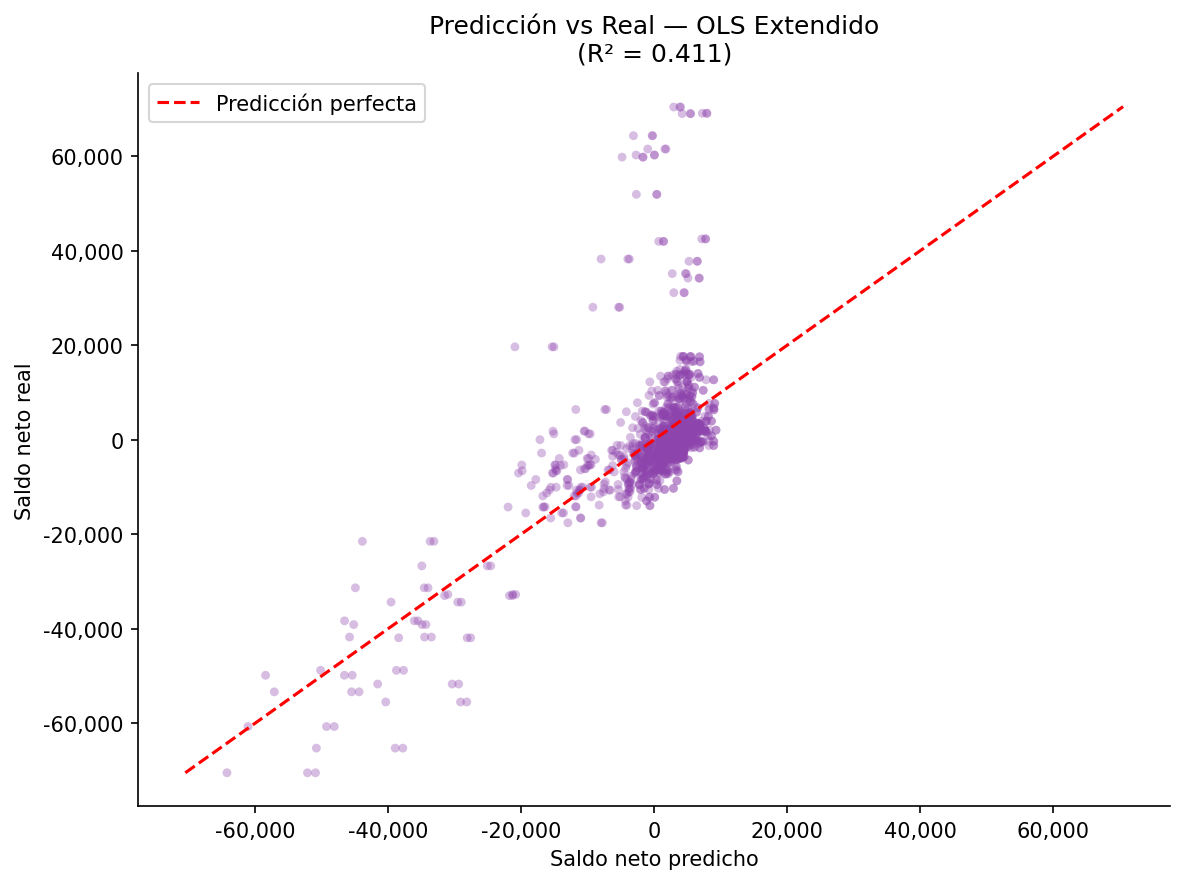

✅ Guardado: 03_prediccion_vs_real.png


In [8]:
#============================================================
# Celda 8 — Predicción vs real
#============================================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(modelo_ext.fittedvalues, sub["saldo_neto"],
           alpha=0.35, s=18, color="#8e44ad", edgecolors="none")

# Línea perfecta
lim = max(abs(sub["saldo_neto"].min()), abs(sub["saldo_neto"].max()))
ax.plot([-lim, lim], [-lim, lim], color="red", linewidth=1.5,
        linestyle="--", label="Predicción perfecta")

ax.set_title(f"Predicción vs Real — OLS Extendido\n(R² = {modelo_ext.rsquared:.3f})")
ax.set_xlabel("Saldo neto predicho")
ax.set_ylabel("Saldo neto real")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()

plt.tight_layout()
plt.savefig(FIGS / "03_prediccion_vs_real.png")
plt.show()
print("✅ Guardado: 03_prediccion_vs_real.png")

In [9]:
#============================================================
# Celda 9 — Tabla resumen final
#============================================================
resumen_final = pd.DataFrame({
    "Modelo": [
        "OLS Base",
        "OLS Extendido",
        "Panel FE (clustered SE)"
    ],
    "Variables independientes": [
        "compraventas + cobertura + población",
        "compraventas + cobertura + población + compraventas_pc",
        "compraventas + cobertura + compraventas_pc (FE provincia)"
    ],
    "R²": [
        round(modelo_base.rsquared, 4),
        round(modelo_ext.rsquared, 4),
        round(fe_result.rsquared_within, 4)
    ],
    "R² adj / within": [
        round(modelo_base.rsquared_adj, 4),
        round(modelo_ext.rsquared_adj, 4),
        round(fe_result.rsquared_within, 4)
    ],
    "AIC": [
        round(modelo_base.aic, 1),
        round(modelo_ext.aic, 1),
        "—"
    ],
    "N obs": [
        int(modelo_base.nobs),
        int(modelo_ext.nobs),
        fe_result.nobs
    ]
})

print("📊 Resumen comparativo de modelos de regresión\n")
print(resumen_final.to_string(index=False))
resumen_final.to_csv(TABLES / "resumen_modelos.csv", index=False)

📊 Resumen comparativo de modelos de regresión

                 Modelo                                  Variables independientes     R²  R² adj / within      AIC  N obs
               OLS Base                      compraventas + cobertura + población 0.4104           0.4091  29582.5   1377
          OLS Extendido    compraventas + cobertura + población + compraventas_pc 0.4115           0.4098  29581.9   1377
Panel FE (clustered SE) compraventas + cobertura + compraventas_pc (FE provincia) 0.0023           0.0023        —   1377


In [10]:
#============================================================
# Celda 10 — Cierre
#============================================================
print("=" * 55)
print("🏁 07_regresion completado")
print("=" * 55)
print(f"\n📁 Figuras  → {FIGS}")
print(f"📁 Tablas   → {TABLES}")
print("\n📈 Figuras generadas:")
for f in sorted(FIGS.glob("*.png")):
    print(f"   ✅ {f.name}")
print("\n📋 Tablas exportadas:")
for f in sorted(TABLES.glob("*.csv")):
    print(f"   ✅ {f.name}")

🏁 07_regresion completado

📁 Figuras  → output/07_regresion/figs
📁 Tablas   → output/07_regresion/tables

📈 Figuras generadas:
   ✅ 01_coeficientes_ols_vs_fe.png
   ✅ 02_diagnostico_residuos.png
   ✅ 03_prediccion_vs_real.png

📋 Tablas exportadas:
   ✅ coeficientes_comparativa.csv
   ✅ comparativa_modelos.csv
   ✅ resumen_modelos.csv
   ✅ vif_multicolinealidad.csv
